# **OptifusionNet**

In [ ]:
# optifusionnet_res_multistage.py
"""
OptiFusionNet - two-resolution training (fast -> high quality)
- Stage A (fast): meta-opt (PSO+ACO) on 128x128 subset + short Adam pretrain
- Stage B (quality): upscale to 256x256, longer Adam -> SGD fine-tune
"""

import os, time, random, math, copy, numpy as np
from glob import glob
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from skimage.metrics import structural_similarity as ssim

# ---------------- CONFIG ----------------
CONFIG = {
    # dataset (paired low/high)
    "low_dir": "/content/drive/MyDrive/IPD/DATA/Train data/lol_dataset/eval15/low",
    "high_dir": "/content/drive/MyDrive/IPD/DATA/Train data/lol_dataset/eval15/high",

    # two resolutions
    "fast_size": 128,    # quick meta-opt/training
    "hq_size": 256,      # final high-quality training

    # training schedule
    "fast_adam_epochs": 6,    # quick pretrain
    "hq_adam_epochs": 20,     # main HQ training
    "sgd_epochs": 8,          # final fine-tune
    "batch_size_fast": 12,
    "batch_size_hq": 8,

    # meta-optimizers (kept small for speed)
    "use_meta_opt": True,
    "meta_subset": 300,    # subset size used in meta-opt
    "pso_iters": 5,
    "pso_particles": 6,
    "pso_eval_epochs": 1,
    "aco_iters": 3,
    "aco_ants": 6,

    # device + reproducibility
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42,

    # save
    "save_path": "optifusionnet_multistage_best.pth",
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
random.seed(CONFIG["seed"])

# ---------------- Utilities ----------------
def psnr(img1, img2):
    mse = F.mse_loss(img1, img2).item()
    if mse == 0:
        return 100.0
    return 20 * math.log10(1.0 / math.sqrt(mse))

def ssim_metric(img1, img2):
    a = img1.detach().cpu().numpy().transpose(1,2,0)
    b = img2.detach().cpu().numpy().transpose(1,2,0)
    return ssim(a, b, data_range=1.0, channel_axis=2)

# ---------------- Dataset ----------------
class LOLDataset(Dataset):
    def __init__(self, low_dir, high_dir, transform=None):
        self.low_dir = low_dir
        self.high_dir = high_dir
        self.low_images = sorted([f for f in os.listdir(low_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
        self.high_images = sorted([f for f in os.listdir(high_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
        assert len(self.low_images) == len(self.high_images), "low/high counts mismatch"
        self.transform = transform
    def __len__(self):
        return len(self.low_images)
    def __getitem__(self, idx):
        lp = os.path.join(self.low_dir, self.low_images[idx])
        hp = os.path.join(self.high_dir, self.high_images[idx])
        l = Image.open(lp).convert("RGB")
        h = Image.open(hp).convert("RGB")
        if self.transform:
            l = self.transform(l)
            h = self.transform(h)
        return l, h

# ---------------- Model blocks ----------------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class ResidualDenoiseBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.act = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(ch)
    def forward(self, x):
        out = self.act(self.conv1(x))
        out = self.bn2(self.conv2(out))
        return x + out

class UpAddBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.proj = None
        if in_ch != skip_ch:
            self.proj = nn.Sequential(nn.Conv2d(in_ch, skip_ch, 1, bias=False), nn.BatchNorm2d(skip_ch), nn.ReLU(inplace=True))
        self.conv = ConvBlock(skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        if self.proj is not None:
            x = self.proj(x)
        # safety: if channels mismatch, project skip
        if x.shape[1] != skip.shape[1]:
            skip = nn.Conv2d(skip.shape[1], x.shape[1], 1).to(skip.device)(skip)
        fused = x + skip
        return self.conv(fused)

# ---------------- OptiFusionNet (addition fusion + denoise blocks) ----------------
class OptiFusionNet(nn.Module):
    def __init__(self, in_ch=3, base_filters=64, res_blocks=3):
        super().__init__()
        self.inc = ConvBlock(in_ch, base_filters)                            # 64
        self.down1 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters, base_filters*2)) #128
        self.down2 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters*2, base_filters*4)) #256
        self.down3 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters*4, base_filters*8)) #512

        bch = base_filters * 8
        bl = [ConvBlock(bch, bch)]
        for _ in range(res_blocks):
            bl.append(ResidualDenoiseBlock(bch))
        self.bottleneck = nn.Sequential(*bl)

        self.up3 = UpAddBlock(in_ch=bch, skip_ch=base_filters*8, out_ch=base_filters*4)
        self.rdb3 = ResidualDenoiseBlock(base_filters*4)
        self.up2 = UpAddBlock(in_ch=base_filters*4, skip_ch=base_filters*4, out_ch=base_filters*2)
        self.rdb2 = ResidualDenoiseBlock(base_filters*2)
        self.up1 = UpAddBlock(in_ch=base_filters*2, skip_ch=base_filters*2, out_ch=base_filters)
        self.rdb1 = ResidualDenoiseBlock(base_filters)

        self.fusion_conv = nn.Sequential(nn.Conv2d(base_filters, base_filters, 3, padding=1), nn.ReLU(inplace=True), nn.Conv2d(base_filters, in_ch, 1))
        self.refiner = ResidualDenoiseBlock(in_ch)

    def forward(self, x):
        x1 = self.inc(x)        # B,64
        x2 = self.down1(x1)     # B,128
        x3 = self.down2(x2)     # B,256
        x4 = self.down3(x3)     # B,512

        b = self.bottleneck(x4) # B,512

        u3 = self.up3(b, x4); u3 = self.rdb3(u3)
        u2 = self.up2(u3, x3); u2 = self.rdb2(u2)
        u1 = self.up1(u2, x2); u1 = self.rdb1(u1)

        # ensure spatial match
        if u1.shape[2:] != x1.shape[2:]:
            u1 = F.interpolate(u1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        # ensure channels match
        if u1.shape[1] != x1.shape[1]:
            proj = nn.Conv2d(u1.shape[1], x1.shape[1], 1).to(u1.device)
            u1 = proj(u1)

        fused = u1 + x1
        res = self.fusion_conv(fused)
        out = torch.clamp(x + self.refiner(res), 0.0, 1.0)
        return out

# ---------------- Loss ----------------
def gradient_loss(output, target):
    dx = output[:, :, :, :-1] - output[:, :, :, 1:]
    dy = output[:, :, :-1, :] - output[:, :, 1:, :]
    return (dx.abs().mean() + dy.abs().mean())

class HybridLoss(nn.Module):
    def __init__(self, a=1.0, b=0.5):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.a = a; self.b = b
    def forward(self, p, t):
        return self.a * self.l1(p, t) + self.b * gradient_loss(p, t)

# ---------------- PSO & ACO (small) ----------------
class Particle:
    def __init__(self, bounds):
        self.position = np.array([random.uniform(lo, hi) for lo,hi in bounds], dtype=np.float32)
        self.velocity = np.array([random.uniform(-(hi-lo), (hi-lo)) for lo,hi in bounds], dtype=np.float32)
        self.best_pos = self.position.copy()
        self.best_score = -np.inf

class PSO:
    def __init__(self, obj_fn, bounds, num_particles=6, max_iter=5, w=0.7, c1=1.5, c2=1.5):
        self.obj_fn = obj_fn; self.bounds = bounds; self.swarm = [Particle(bounds) for _ in range(num_particles)]
        self.max_iter = max_iter; self.w=w; self.c1=c1; self.c2=c2
        self.global_best_pos = None; self.global_best_score = -np.inf
    def clip(self,pos):
        for i,(lo,hi) in enumerate(self.bounds): pos[i]=np.clip(pos[i], lo, hi)
        return pos
    def optimize(self, verbose=True):
        for it in range(self.max_iter):
            if verbose: print(f"[PSO] iter {it+1}/{self.max_iter}")
            for p in self.swarm:
                p.position = self.clip(p.position)
                score = self.obj_fn(p.position)
                if score > p.best_score:
                    p.best_score = score; p.best_pos = p.position.copy()
                if score > self.global_best_score:
                    self.global_best_score = score; self.global_best_pos = p.position.copy()
                if verbose:
                    print(f"  particle score={score:.4f}")
            for p in self.swarm:
                r1 = np.random.rand(len(self.bounds)); r2 = np.random.rand(len(self.bounds))
                cognitive = self.c1 * r1 * (p.best_pos - p.position)
                social = self.c2 * r2 * (self.global_best_pos - p.position)
                p.velocity = self.w * p.velocity + cognitive + social
                p.position = p.position + p.velocity
                p.position = self.clip(p.position)
        return self.global_best_pos, self.global_best_score

class ACO:
    def __init__(self, obj_fn, bounds, n_ants=6, n_best=3, n_iter=3, evaporation=0.5):
        self.obj_fn = obj_fn; self.bounds = bounds; self.n_ants=n_ants; self.n_best=n_best; self.n_iter=n_iter; self.evap=evaporation
        self.pher = [1.0 for _ in bounds]
    def sample(self):
        return [random.uniform(lo,hi) for lo,hi in self.bounds]
    def optimize(self, verbose=True):
        best=None; best_score=-np.inf
        for it in range(self.n_iter):
            sols=[]
            for _ in range(self.n_ants):
                p = self.sample(); s = self.obj_fn(p); sols.append((p,s))
            sols.sort(key=lambda x: x[1], reverse=True); local = sols[:self.n_best]
            if local[0][1] > best_score:
                best_score = local[0][1]; best = local[0][0]
            for i in range(len(self.pher)):
                self.pher[i] = (1-self.evap)*self.pher[i]
                for params, score in local:
                    self.pher[i] += (score/(best_score+1e-9))
            if verbose: print(f"[ACO] iter {it+1}/{self.n_iter} best_local={local[0][1]:.4f}")
        return best, best_score

# ---------------- Objective factory for meta-opt ----------------
def make_objective(train_loader, val_loader, device='cpu', eval_epochs=1):
    def objective(pos):
        lr, momentum, wd = float(pos[0]), float(pos[1]), float(pos[2])
        model = OptiFusionNet().to(device)
        criterion = HybridLoss().to(device)
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=wd)
        scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)
        model.train()
        for e in range(eval_epochs):
            for low, high in train_loader:
                low, high = low.to(device), high.to(device)
                out = model(low); loss = criterion(out, high)
                opt.zero_grad(); loss.backward(); opt.step()
            scheduler.step()
        # eval
        model.eval(); tot_psnr=0.0; cnt=0
        with torch.no_grad():
            for low, high in val_loader:
                low, high = low.to(device), high.to(device)
                out = model(low)
                for i in range(out.shape[0]):
                    tot_psnr += psnr(out[i].clamp(0,1), high[i].clamp(0,1)); cnt+=1
        return tot_psnr / max(1, cnt)
    return objective

# ---------------- Training / Evaluation helpers ----------------
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train(); running=0.0; n=0
    for low, high in loader:
        low, high = low.to(device), high.to(device)
        out = model(low); loss = criterion(out, high)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running += loss.item()*low.size(0); n += low.size(0)
    return running / max(1, n)

def eval_one_epoch(model, loader, criterion, device):
    model.eval(); running=0.0; n=0; tot_psnr=0.0; tot_ssim=0.0
    with torch.no_grad():
        for low, high in loader:
            low, high = low.to(device), high.to(device)
            out = model(low); loss = criterion(out, high)
            running += loss.item()*low.size(0); n+=low.size(0)
            for i in range(out.shape[0]):
                tot_psnr += psnr(out[i].clamp(0,1), high[i].clamp(0,1))
                tot_ssim += ssim_metric(out[i].clamp(0,1), high[i].clamp(0,1))
    return running / max(1, n), tot_psnr / max(1,1), tot_ssim / max(1,1)

# ---------------- Data loaders util ----------------
def prepare_dataloaders(low_dir, high_dir, img_size, batch_size, subset=None):
    tf = transforms.Compose([transforms.Resize((img_size, img_size)), transforms.ToTensor()])
    ds = LOLDataset(low_dir, high_dir, transform=tf)
    n = len(ds)
    if subset and subset < n:
        idx = list(range(n)); random.shuffle(idx); idx = idx[:subset]; ds = Subset(ds, idx)
    total = len(ds)
    split = max(1, int(0.9 * total))
    train = Subset(ds, list(range(0, split))); val = Subset(ds, list(range(split, total)))
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader

# ---------------- Full multistage pipeline ----------------
def multistage_train():
    device = CONFIG["device"]
    print("Device:", device)

    # ---- Stage 0: meta-opt on small 128 subset (fast) ----
    if CONFIG["use_meta_opt"]:
        print("Running meta-optimization (PSO + ACO) on fast resolution subset...")
        tr_sub, val_sub = prepare_dataloaders(CONFIG["low_dir"], CONFIG["high_dir"],
                                              img_size=CONFIG["fast_size"],
                                              batch_size=CONFIG["batch_size_fast"],
                                              subset=CONFIG["meta_subset"])
        objective = make_objective(tr_sub, val_sub, device=device, eval_epochs=CONFIG["pso_eval_epochs"])
        bounds = [(1e-5, 1e-2), (0.0, 0.99), (0.0, 5e-4)]
        pso = PSO(obj_fn=objective, bounds=bounds, num_particles=CONFIG["pso_particles"], max_iter=CONFIG["pso_iters"])
        best_pos_pso, best_score_pso = pso.optimize(verbose=True)
        print("[PSO] best:", best_pos_pso, "score:", best_score_pso)

        aco = ACO(obj_fn=objective, bounds=bounds, n_ants=CONFIG["aco_ants"], n_best=3, n_iter=CONFIG["aco_iters"])
        best_pos_aco, best_score_aco = aco.optimize(verbose=True)
        print("[ACO] best:", best_pos_aco, "score:", best_score_aco)

        # choose best
        if best_score_aco > best_score_pso:
            chosen = best_pos_aco; method = "ACO"; score = best_score_aco
        else:
            chosen = best_pos_pso; method = "PSO"; score = best_score_pso
        lr_meta, mom_meta, wd_meta = float(chosen[0]), float(chosen[1]), float(chosen[2])
        print("Meta chosen:", method, "-> lr", lr_meta, "mom", mom_meta, "wd", wd_meta)
    else:
        lr_meta, mom_meta, wd_meta = 1e-4, 0.9, 1e-4

    # ---- Stage 1: fast Adam pretrain at 128 ----
    print("Stage 1: Fast Adam pretrain @", CONFIG["fast_size"])
    train_fast, val_fast = prepare_dataloaders(CONFIG["low_dir"], CONFIG["high_dir"],
                                               img_size=CONFIG["fast_size"],
                                               batch_size=CONFIG["batch_size_fast"],
                                               subset=None)
    model = OptiFusionNet().to(device)
    criterion = HybridLoss().to(device)
    optA = torch.optim.Adam(model.parameters(), lr=lr_meta, weight_decay=wd_meta)
    schedA = torch.optim.lr_scheduler.StepLR(optA, step_size=5, gamma=0.5)
    best_val = float('inf'); best_state=None

    for epoch in range(1, CONFIG["fast_adam_epochs"]+1):
        t0=time.time()
        tr = train_one_epoch(model, train_fast, optA, criterion, device)
        val_loss, val_psnr, val_ssim = eval_one_epoch(model, val_fast, criterion, device)
        schedA.step()
        print(f"[FastAdam] E{epoch}/{CONFIG['fast_adam_epochs']} tr={tr:.4f} val={val_loss:.4f} PSNR={val_psnr:.2f} SSIM={val_ssim:.4f} time={time.time()-t0:.1f}s")
        if val_loss < best_val:
            best_val = val_loss; best_state = copy.deepcopy(model.state_dict()); torch.save({'epoch':epoch,'model_state':best_state,'val_loss':val_loss}, CONFIG["save_path"])

    # ---- Stage 2: upscale to HQ (256), reload weights, continue Adam training ----
    print("Stage 2: HQ training @", CONFIG["hq_size"])
    # reload model weights from fast stage
    if best_state is not None:
        model.load_state_dict(best_state)

    train_hq, val_hq = prepare_dataloaders(CONFIG["low_dir"], CONFIG["high_dir"],
                                           img_size=CONFIG["hq_size"],
                                           batch_size=CONFIG["batch_size_hq"],
                                           subset=None)
    # Optionally lower LR slightly for HQ Adam
    hq_lr = max(lr_meta * 0.5, 1e-6)
    optA_hq = torch.optim.Adam(model.parameters(), lr=hq_lr, weight_decay=wd_meta)
    schedA_hq = torch.optim.lr_scheduler.StepLR(optA_hq, step_size=7, gamma=0.5)

    for epoch in range(1, CONFIG["hq_adam_epochs"]+1):
        t0=time.time()
        tr = train_one_epoch(model, train_hq, optA_hq, criterion, device)
        val_loss, val_psnr, val_ssim = eval_one_epoch(model, val_hq, criterion, device)
        schedA_hq.step()
        print(f"[HQ-Adam] E{epoch}/{CONFIG['hq_adam_epochs']} tr={tr:.4f} val={val_loss:.4f} PSNR={val_psnr:.2f} SSIM={val_ssim:.4f} time={time.time()-t0:.1f}s")
        if val_loss < best_val:
            best_val = val_loss; best_state = copy.deepcopy(model.state_dict()); torch.save({'epoch':epoch+CONFIG['fast_adam_epochs'],'model_state':best_state,'val_loss':val_loss}, CONFIG["save_path"])

    # ---- Stage 3: final SGD fine-tune (momentum) at HQ size ----
    print("Stage 3: Final SGD fine-tune")
    sgd_lr = max(hq_lr * 0.1, 1e-7)
    optS = torch.optim.SGD(model.parameters(), lr=sgd_lr, momentum=mom_meta, weight_decay=wd_meta)
    schedS = torch.optim.lr_scheduler.StepLR(optS, step_size=6, gamma=0.5)

    for epoch in range(1, CONFIG["sgd_epochs"]+1):
        t0=time.time()
        tr = train_one_epoch(model, train_hq, optS, criterion, device)
        val_loss, val_psnr, val_ssim = eval_one_epoch(model, val_hq, criterion, device)
        schedS.step()
        print(f"[SGD] E{epoch}/{CONFIG['sgd_epochs']} tr={tr:.4f} val={val_loss:.4f} PSNR={val_psnr:.2f} SSIM={val_ssim:.4f} time={time.time()-t0:.1f}s")
        if val_loss < best_val:
            best_val = val_loss; best_state = copy.deepcopy(model.state_dict()); torch.save({'epoch':epoch+CONFIG['hq_adam_epochs']+CONFIG['fast_adam_epochs'],'model_state':best_state,'val_loss':val_loss}, CONFIG["save_path"])

    print("Training complete. Best val loss:", best_val)
    print("Model checkpoint:", CONFIG["save_path"])
    return model

# ---------------- Inference helper ----------------
def enhance_folder(model_path, input_folder, output_folder, device=None, size=None):
    if device is None:
        device = CONFIG["device"]
    ckpt = torch.load(model_path, map_location=device)
    model = OptiFusionNet().to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    if size is None:
        size = CONFIG["hq_size"]
    tf = transforms.Compose([transforms.Resize((size,size)), transforms.ToTensor()])
    inv = transforms.ToPILImage()
    os.makedirs(output_folder, exist_ok=True)
    with torch.no_grad():
        for p in sorted(glob(os.path.join(input_folder,'*'))):
            try:
                img = Image.open(p).convert('RGB'); w,h = img.size
                inp = tf(img).unsqueeze(0).to(device)
                out = model(inp)
                out_img = inv(out.squeeze(0).cpu().clamp(0,1)).resize((w,h), Image.BICUBIC)
                out_img.save(os.path.join(output_folder, os.path.basename(p)))
            except Exception as e:
                print("skip", p, e)
    print("Saved enhanced images to", output_folder)

# ---------------- Main ----------------
if __name__ == "__main__":
    start = time.time()
    trained_model = multistage_train()
    print("Total elapsed:", time.time()-start)
    # Example inference:
    # enhance_folder(CONFIG["save_path"], "/path/to/psr_inputs", "/path/to/psr_outputs")


Device: cuda
Running meta-optimization (PSO + ACO) on fast resolution subset...
[PSO] iter 1/5
  particle score=8.5924
  particle score=7.3860
  particle score=8.4718
  particle score=10.1753
  particle score=8.1888
  particle score=11.4079
[PSO] iter 2/5
  particle score=8.4976
  particle score=9.5913
  particle score=9.5988
  particle score=9.4770
  particle score=8.9334
  particle score=7.8006
[PSO] iter 3/5
  particle score=9.4976
  particle score=10.2653
  particle score=7.5855
  particle score=10.1309
  particle score=8.7356
  particle score=12.0185
[PSO] iter 4/5
  particle score=9.2917
  particle score=8.5784
  particle score=8.7155
  particle score=10.3759
  particle score=9.1133
  particle score=7.4408
[PSO] iter 5/5
  particle score=10.2227
  particle score=9.6094
  particle score=9.3503
  particle score=9.9204
  particle score=9.3109
  particle score=8.5030
[PSO] best: [1.00000000e-02 8.33826259e-01 3.15110384e-04] score: 12.018484960786777
[ACO] iter 1/3 best_local=10.5327

In [ ]:
import os, time, random, math, copy, numpy as np
from glob import glob
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from skimage.metrics import structural_similarity as ssim
# Removed matplotlib import from here as it will be in a new cell

# ---------------- CONFIG ----------------
CONFIG = {
    # dataset (paired low/high)
    "low_dir": "/content/drive/MyDrive/IPD/DATA/Train data/lol_dataset/our485/low",
    "high_dir": "/content/drive/MyDrive/IPD/DATA/Train data/lol_dataset/our485/high",

    # two resolutions
    "fast_size": 128,    # quick meta-opt/training
    "hq_size": 256,      # final high-quality training

    # training schedule
    "fast_adam_epochs": 6,    # quick pretrain
    "hq_adam_epochs": 20,     # main HQ training
    "sgd_epochs": 8,          # final fine-tune
    "batch_size_fast": 12,
    "batch_size_hq": 8,

    # meta-optimizers (kept small for speed)
    "use_meta_opt": True,
    "meta_subset": 300,    # subset size used in meta-opt
    "pso_iters": 5,
    "pso_particles": 6,
    "pso_eval_epochs": 1,
    "aco_iters": 3,
    "aco_ants": 6,

    # device + reproducibility
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42,

    # save
    "save_path": "optifusionnet_multistage_best.pth",
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
random.seed(CONFIG["seed"])

# ---------------- Utilities ----------------
def psnr(img1, img2):
    mse = F.mse_loss(img1, img2).item()
    if mse == 0:
        return 100.0
    return 20 * math.log10(1.0 / math.sqrt(mse))

def ssim_metric(img1, img2):
    a = img1.detach().cpu().numpy().transpose(1,2,0)
    b = img2.detach().cpu().numpy().transpose(1,2,0)
    return ssim(a, b, data_range=1.0, channel_axis=2)

# ---------------- Dataset ----------------
class LOLDataset(Dataset):
    def __init__(self, low_dir, high_dir, transform=None):
        self.low_dir = low_dir
        self.high_dir = high_dir
        self.low_images = sorted([f for f in os.listdir(low_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
        self.high_images = sorted([f for f in os.listdir(high_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
        assert len(self.low_images) == len(self.high_images), "low/high counts mismatch"
        self.transform = transform
    def __len__(self):
        return len(self.low_images)
    def __getitem__(self, idx):
        lp = os.path.join(self.low_dir, self.low_images[idx])
        hp = os.path.join(self.high_dir, self.high_images[idx])
        l = Image.open(lp).convert("RGB")
        h = Image.open(hp).convert("RGB")
        if self.transform:
            l = self.transform(l)
            h = self.transform(h)
        return l, h

# ---------------- Model blocks ----------------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class ResidualDenoiseBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.act = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(ch)
    def forward(self, x):
        out = self.act(self.conv1(x))
        out = self.bn2(self.conv2(out))
        return x + out

class UpAddBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.proj = None
        if in_ch != skip_ch:
            self.proj = nn.Sequential(nn.Conv2d(in_ch, skip_ch, 1, bias=False), nn.BatchNorm2d(skip_ch), nn.ReLU(inplace=True))
        self.conv = ConvBlock(skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        if self.proj is not None:
            x = self.proj(x)
        # safety: if channels mismatch, project skip
        if x.shape[1] != skip.shape[1]:
            skip = nn.Conv2d(skip.shape[1], x.shape[1], 1).to(skip.device)(skip)
        fused = x + skip
        return self.conv(fused)

# ---------------- OptiFusionNet (addition fusion + denoise blocks) ----------------
class OptiFusionNet(nn.Module):
    def __init__(self, in_ch=3, base_filters=64, res_blocks=3):
        super().__init__()
        self.inc = ConvBlock(in_ch, base_filters)                            # 64
        self.down1 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters, base_filters*2)) #128
        self.down2 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters*2, base_filters*4)) #256
        self.down3 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters*4, base_filters*8)) #512

        bch = base_filters * 8
        bl = [ConvBlock(bch, bch)]
        for _ in range(res_blocks):
            bl.append(ResidualDenoiseBlock(bch))
        self.bottleneck = nn.Sequential(*bl)

        self.up3 = UpAddBlock(in_ch=bch, skip_ch=base_filters*8, out_ch=base_filters*4)
        self.rdb3 = ResidualDenoiseBlock(base_filters*4)
        self.up2 = UpAddBlock(in_ch=base_filters*4, skip_ch=base_filters*4, out_ch=base_filters*2)
        self.rdb2 = ResidualDenoiseBlock(base_filters*2)
        self.up1 = UpAddBlock(in_ch=base_filters*2, skip_ch=base_filters*2, out_ch=base_filters)
        self.rdb1 = ResidualDenoiseBlock(base_filters)

        self.fusion_conv = nn.Sequential(nn.Conv2d(base_filters, base_filters, 3, padding=1), nn.ReLU(inplace=True), nn.Conv2d(base_filters, in_ch, 1))
        self.refiner = ResidualDenoiseBlock(in_ch)

    def forward(self, x):
        x1 = self.inc(x)        # B,64
        x2 = self.down1(x1)     # B,128
        x3 = self.down2(x2)     # B,256
        x4 = self.down3(x3)     # B,512

        b = self.bottleneck(x4) # B,512

        u3 = self.up3(b, x4); u3 = self.rdb3(u3)
        u2 = self.up2(u3, x3); u2 = self.rdb2(u2)
        u1 = self.up1(u2, x2); u1 = self.rdb1(u1)

        # ensure spatial match
        if u1.shape[2:] != x1.shape[2:]:
            u1 = F.interpolate(u1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        # ensure channels match
        if u1.shape[1] != x1.shape[1]:
            proj = nn.Conv2d(u1.shape[1], x1.shape[1], 1).to(u1.device)
            u1 = proj(u1)

        fused = u1 + x1
        res = self.fusion_conv(fused)
        out = torch.clamp(x + self.refiner(res), 0.0, 1.0)
        return out

# ---------------- Loss ----------------
def gradient_loss(output, target):
    dx = output[:, :, :, :-1] - output[:, :, :, 1:]
    dy = output[:, :, :-1, :] - output[:, :, 1:, :]
    return (dx.abs().mean() + dy.abs().mean())

class HybridLoss(nn.Module):
    def __init__(self, a=1.0, b=0.5):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.a = a; self.b = b
    def forward(self, p, t):
        return self.a * self.l1(p, t) + self.b * gradient_loss(p, t)

# ---------------- PSO & ACO (small) ----------------
class Particle:
    def __init__(self, bounds):
        self.position = np.array([random.uniform(lo, hi) for lo,hi in bounds], dtype=np.float32)
        self.velocity = np.array([random.uniform(-(hi-lo), (hi-lo)) for lo,hi in bounds], dtype=np.float32)
        self.best_pos = self.position.copy()
        self.best_score = -np.inf

class PSO:
    def __init__(self, obj_fn, bounds, num_particles=6, max_iter=5, w=0.7, c1=1.5, c2=1.5):
        self.obj_fn = obj_fn; self.bounds = bounds; self.swarm = [Particle(bounds) for _ in range(num_particles)]
        self.max_iter = max_iter; self.w=w; self.c1=c1; self.c2=c2
        self.global_best_pos = None; self.global_best_score = -np.inf
    def clip(self,pos):
        for i,(lo,hi) in enumerate(self.bounds): pos[i]=np.clip(pos[i], lo, hi)
        return pos
    def optimize(self, verbose=True):
        for it in range(self.max_iter):
            if verbose: print(f"[PSO] iter {it+1}/{self.max_iter}")
            for p in self.swarm:
                p.position = self.clip(p.position)
                score = self.obj_fn(p.position)
                if score > p.best_score:
                    p.best_score = score; p.best_pos = p.position.copy()
                if score > self.global_best_score:
                    self.global_best_score = score; self.global_best_pos = p.position.copy()
                if verbose:
                    print(f"  particle score={score:.4f}")
            for p in self.swarm:
                r1 = np.random.rand(len(self.bounds)); r2 = np.random.rand(len(self.bounds))
                cognitive = self.c1 * r1 * (p.best_pos - p.position)
                social = self.c2 * r2 * (self.global_best_pos - p.position)
                p.velocity = self.w * p.velocity + cognitive + social
                p.position = p.position + p.velocity
                p.position = self.clip(p.position)
        return self.global_best_pos, self.global_best_score

class ACO:
    def __init__(self, obj_fn, bounds, n_ants=6, n_best=3, n_iter=3, evaporation=0.5):
        self.obj_fn = obj_fn; self.bounds = bounds; self.n_ants=n_ants; self.n_best=n_best; self.n_iter=n_iter; self.evap=evaporation
        self.pher = [1.0 for _ in bounds]
    def sample(self):
        return [random.uniform(lo,hi) for lo,hi in self.bounds]
    def optimize(self, verbose=True):
        best=None; best_score=-np.inf
        for it in range(self.n_iter):
            sols=[]
            for _ in range(self.n_ants):
                p = self.sample(); s = self.obj_fn(p); sols.append((p,s))
            sols.sort(key=lambda x: x[1], reverse=True); local = sols[:self.n_best]
            if local[0][1] > best_score:
                best_score = local[0][1]; best = local[0][0]
            for i in range(len(self.pher)):
                self.pher[i] = (1-self.evap)*self.pher[i]
                for params, score in local:
                    self.pher[i] += (score/(best_score+1e-9))
            if verbose: print(f"[ACO] iter {it+1}/{self.n_iter} best_local={local[0][1]:.4f}")
        return best, best_score

# ---------------- Objective factory for meta-opt ----------------
def make_objective(train_loader, val_loader, device='cpu', eval_epochs=1):
    def objective(pos):
        lr, momentum, wd = float(pos[0]), float(pos[1]), float(pos[2])
        model = OptiFusionNet().to(device)
        criterion = HybridLoss().to(device)
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=wd)
        scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)
        model.train()
        for e in range(eval_epochs):
            for low, high in train_loader:
                low, high = low.to(device), high.to(device)
                out = model(low); loss = criterion(out, high)
                opt.zero_grad(); loss.backward(); opt.step()
            scheduler.step()
        # eval
        model.eval(); tot_psnr=0.0; cnt=0
        with torch.no_grad():
            for low, high in val_loader:
                low, high = low.to(device), high.to(device)
                out = model(low)
                for i in range(out.shape[0]):
                    tot_psnr += psnr(out[i].clamp(0,1), high[i].clamp(0,1)); cnt+=1
        return tot_psnr / max(1, cnt)
    return objective

# ---------------- Training / Evaluation helpers ----------------
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train(); running=0.0; n=0
    for low, high in loader:
        low, high = low.to(device), high.to(device)
        out = model(low); loss = criterion(out, high)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running += loss.item()*low.size(0); n += low.size(0)
    return running / max(1, n)

def eval_one_epoch(model, loader, criterion, device):
    model.eval(); running=0.0; n=0; tot_psnr=0.0; tot_ssim=0.0
    with torch.no_grad():
        for low, high in loader:
            low, high = low.to(device), high.to(device)
            out = model(low); loss = criterion(out, high)
            running += loss.item()*low.size(0); n+=low.size(0)
            for i in range(out.shape[0]):
                tot_psnr += psnr(out[i].clamp(0,1), high[i].clamp(0,1))
                tot_ssim += ssim_metric(out[i].clamp(0,1), high[i].clamp(0,1))
    return running / max(1, n), tot_psnr / max(1,1), tot_ssim / max(1,1)

# ---------------- Data loaders util ----------------
def prepare_dataloaders(low_dir, high_dir, img_size, batch_size, subset=None):
    tf = transforms.Compose([transforms.Resize((img_size, img_size)), transforms.ToTensor()])
    ds = LOLDataset(low_dir, high_dir, transform=tf)
    n = len(ds)
    if subset and subset < n:
        idx = list(range(n)); random.shuffle(idx); idx = idx[:subset]; ds = Subset(ds, idx)
    total = len(ds)
    split = max(1, int(0.9 * total))
    train = Subset(ds, list(range(0, split))); val = Subset(ds, list(range(split, total)))
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader

# ---------------- Full multistage pipeline ----------------
def multistage_train():
    device = CONFIG["device"]
    print("Device:", device)

    # Lists to store metrics
    history = defaultdict(list)

    # ---- Stage 0: meta-opt on small 128 subset (fast) ----
    if CONFIG["use_meta_opt"]:
        print("Running meta-optimization (PSO + ACO) on fast resolution subset...")
        tr_sub, val_sub = prepare_dataloaders(CONFIG["low_dir"], CONFIG["high_dir"],
                                              img_size=CONFIG["fast_size"],
                                              batch_size=CONFIG["batch_size_fast"],
                                              subset=CONFIG["meta_subset"])
        objective = make_objective(tr_sub, val_sub, device=device, eval_epochs=CONFIG["pso_eval_epochs"])
        bounds = [(1e-5, 1e-2), (0.0, 0.99), (0.0, 5e-4)]
        pso = PSO(obj_fn=objective, bounds=bounds, num_particles=CONFIG["pso_particles"], max_iter=CONFIG["pso_iters"])
        best_pos_pso, best_score_pso = pso.optimize(verbose=True)
        print("[PSO] best:", best_pos_pso, "score:", best_score_pso)

        aco = ACO(obj_fn=objective, bounds=bounds, n_ants=CONFIG["aco_ants"], n_best=3, n_iter=CONFIG["aco_iters"])
        best_pos_aco, best_score_aco = aco.optimize(verbose=True)
        print("[ACO] best:", best_pos_aco, "score:", best_score_aco)

        # choose best
        if best_score_aco > best_score_pso:
            chosen = best_pos_aco; method = "ACO"; score = best_score_aco
        else:
            chosen = best_pos_pso; method = "PSO"; score = best_score_pso
        lr_meta, mom_meta, wd_meta = float(chosen[0]), float(chosen[1]), float(chosen[2])
        print("Meta chosen:", method, "-> lr", lr_meta, "mom", mom_meta, "wd", wd_meta)
    else:
        lr_meta, mom_meta, wd_meta = 1e-4, 0.9, 1e-4

    # ---- Stage 1: fast Adam pretrain at 128 ----
    print("Stage 1: Fast Adam pretrain @", CONFIG["fast_size"])
    train_fast, val_fast = prepare_dataloaders(CONFIG["low_dir"], CONFIG["high_dir"],
                                               img_size=CONFIG["fast_size"],
                                               batch_size=CONFIG["batch_size_fast"],
                                               subset=None)
    model = OptiFusionNet().to(device)
    criterion = HybridLoss().to(device)
    optA = torch.optim.Adam(model.parameters(), lr=lr_meta, weight_decay=wd_meta)
    schedA = torch.optim.lr_scheduler.StepLR(optA, step_size=5, gamma=0.5)
    best_val = float('inf'); best_state=None

    for epoch in range(1, CONFIG["fast_adam_epochs"]+1):
        t0=time.time()
        tr = train_one_epoch(model, train_fast, optA, criterion, device)
        val_loss, val_psnr, val_ssim = eval_one_epoch(model, val_fast, criterion, device)
        schedA.step()

        history['fast_adam_train_loss'].append(tr)
        history['fast_adam_val_loss'].append(val_loss)
        history['fast_adam_val_psnr'].append(val_psnr)
        history['fast_adam_val_ssim'].append(val_ssim)

        print(f"[FastAdam] E{epoch}/{CONFIG['fast_adam_epochs']} tr={tr:.4f} val={val_loss:.4f} PSNR={val_psnr:.2f} SSIM={val_ssim:.4f} time={time.time()-t0:.1f}s")
        if val_loss < best_val:
            best_val = val_loss; best_state = copy.deepcopy(model.state_dict()); torch.save({'epoch':epoch,'model_state':best_state,'val_loss':val_loss}, CONFIG["save_path"])

    # ---- Stage 2: upscale to HQ (256), reload weights, continue Adam training ----
    print("Stage 2: HQ training @", CONFIG["hq_size"])
    # reload model weights from fast stage
    if best_state is not None:
        model.load_state_dict(best_state)

    train_hq, val_hq = prepare_dataloaders(CONFIG["low_dir"], CONFIG["high_dir"],
                                           img_size=CONFIG["hq_size"],
                                           batch_size=CONFIG["batch_size_hq"],
                                           subset=None)
    # Optionally lower LR slightly for HQ Adam
    hq_lr = max(lr_meta * 0.5, 1e-6)
    optA_hq = torch.optim.Adam(model.parameters(), lr=hq_lr, weight_decay=wd_meta)
    schedA_hq = torch.optim.lr_scheduler.StepLR(optA_hq, step_size=7, gamma=0.5)

    for epoch in range(1, CONFIG["hq_adam_epochs"]+1):
        t0=time.time()
        tr = train_one_epoch(model, train_hq, optA_hq, criterion, device)
        val_loss, val_psnr, val_ssim = eval_one_epoch(model, val_hq, criterion, device)
        schedA_hq.step()

        history['hq_adam_train_loss'].append(tr)
        history['hq_adam_val_loss'].append(val_loss)
        history['hq_adam_val_psnr'].append(val_psnr)
        history['hq_adam_val_ssim'].append(val_ssim)

        print(f"[HQ-Adam] E{epoch}/{CONFIG['hq_adam_epochs']} tr={tr:.4f} val={val_loss:.4f} PSNR={val_psnr:.2f} SSIM={val_ssim:.4f} time={time.time()-t0:.1f}s")
        if val_loss < best_val:
            best_val = val_loss; best_state = copy.deepcopy(model.state_dict()); torch.save({'epoch':epoch+CONFIG['fast_adam_epochs'],'model_state':best_state,'val_loss':val_loss}, CONFIG["save_path"])

    # ---- Stage 3: final SGD fine-tune (momentum) at HQ size ----
    print("Stage 3: Final SGD fine-tune")
    sgd_lr = max(hq_lr * 0.1, 1e-7)
    optS = torch.optim.SGD(model.parameters(), lr=sgd_lr, momentum=mom_meta, weight_decay=wd_meta)
    schedS = torch.optim.lr_scheduler.StepLR(optS, step_size=6, gamma=0.5)

    for epoch in range(1, CONFIG["sgd_epochs"]+1):
        t0=time.time()
        tr = train_one_epoch(model, train_hq, optS, criterion, device)
        val_loss, val_psnr, val_ssim = eval_one_epoch(model, val_hq, criterion, device)
        schedS.step()

        history['sgd_train_loss'].append(tr)
        history['sgd_val_loss'].append(val_loss)
        history['sgd_val_psnr'].append(val_psnr)
        history['sgd_val_ssim'].append(val_ssim)

        print(f"[SGD] E{epoch}/{CONFIG['sgd_epochs']} tr={tr:.4f} val={val_loss:.4f} PSNR={val_psnr:.2f} SSIM={val_ssim:.4f} time={time.time()-t0:.1f}s")
        if val_loss < best_val:
            best_val = val_loss; best_state = copy.deepcopy(model.state_dict()); torch.save({'epoch':epoch+CONFIG['hq_adam_epochs']+CONFIG['fast_adam_epochs'],'model_state':best_state,'val_loss':val_loss}, CONFIG["save_path"])

    print("Training complete. Best val loss:", best_val)
    print("Model checkpoint:", CONFIG["save_path"])
    return model, history # Return history as well

# ---------------- Inference helper ----------------
def enhance_folder(model_path, input_folder, output_folder, device=None, size=None):
    if device is None:
        device = CONFIG["device"]
    ckpt = torch.load(model_path, map_location=device)
    model = OptiFusionNet().to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    if size is None:
        size = CONFIG["hq_size"]
    tf = transforms.Compose([transforms.Resize((size,size)), transforms.ToTensor()])
    inv = transforms.ToPILImage()
    os.makedirs(output_folder, exist_ok=True)
    with torch.no_grad():
        for p in sorted(glob(os.path.join(input_folder,'*'))):
            try:
                img = Image.open(p).convert('RGB'); w,h = img.size
                inp = tf(img).unsqueeze(0).to(device)
                out = model(inp)
                out_img = inv(out.squeeze(0).cpu().clamp(0,1)).resize((w,h), Image.BICUBIC)
                out_img.save(os.path.join(output_folder, os.path.basename(p)))
            except Exception as e:
                print("skip", p, e)
    print("Saved enhanced images to", output_folder)

# ---------------- Main ----------------
if __name__ == "__main__":
    start = time.time()
    trained_model, training_history = multistage_train() # Get training history
    print("Total elapsed:", time.time()-start)

    # Example inference (plotting is moved to a new cell):
    # enhance_folder(CONFIG["save_path"], "/path/to/psr_inputs", "/path/to/psr_outputs")

Device: cuda
Running meta-optimization (PSO + ACO) on fast resolution subset...
[PSO] iter 1/5
  particle score=11.9564
  particle score=8.2575
  particle score=14.1362
  particle score=13.7121
  particle score=8.5128
  particle score=14.5851
[PSO] iter 2/5
  particle score=7.5866
  particle score=10.6951
  particle score=14.4899
  particle score=9.5848
  particle score=8.1263
  particle score=7.8318
[PSO] iter 3/5
  particle score=9.6598
  particle score=15.0841
  particle score=7.0873
  particle score=14.4182
  particle score=9.3237
  particle score=9.8708
[PSO] iter 4/5
  particle score=10.5716
  particle score=9.1221
  particle score=15.0266
  particle score=15.7914
  particle score=8.3713
  particle score=8.1724
[PSO] iter 5/5
  particle score=15.1179
  particle score=14.8293
  particle score=8.5634
  particle score=15.5606
  particle score=13.2347
  particle score=8.8268
[PSO] best: [6.26734830e-03 9.90000000e-01 4.67987795e-04] score: 15.791381331458297
[ACO] iter 1/3 best_local

In [ ]:
# optifusionnet_res_multistage.py
"""
OptiFusionNet - two-resolution training (fast -> high quality)
- Stage A (fast): meta-opt (PSO+ACO) on 128x128 subset + short Adam pretrain
- Stage B (quality): upscale to 256x256, longer Adam -> SGD fine-tune
"""

import os, time, random, math, copy, numpy as np
from glob import glob
from PIL import Image
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms
from skimage.metrics import structural_similarity as ssim

# ---------------- CONFIG ----------------
CONFIG = {
    # dataset (paired low/high) - now uses a single source directory
    "image_source_dir": "/content/drive/MyDrive/IPD/isro_data",

    # two resolutions
    "fast_size": 128,    # quick meta-opt/training
    "hq_size": 256,      # final high-quality training

    # training schedule
    "fast_adam_epochs": 6,    # quick pretrain
    "hq_adam_epochs": 20,     # main HQ training
    "sgd_epochs": 8,          # final fine-tune
    "batch_size_fast": 12,
    "batch_size_hq": 8,

    # meta-optimizers (kept small for speed)
    "use_meta_opt": True,
    "meta_subset": 300,    # subset size used in meta-opt
    "pso_iters": 5,
    "pso_particles": 6,
    "pso_eval_epochs": 1,
    "aco_iters": 3,
    "aco_ants": 6,

    # device + reproducibility
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42,

    # save
    "save_path": "optifusionnet_multistage_best.pth",
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
random.seed(CONFIG["seed"])

# ---------------- Utilities ----------------
def psnr(img1, img2):
    mse = F.mse_loss(img1, img2).item()
    if mse == 0:
        return 100.0
    return 20 * math.log10(1.0 / math.sqrt(mse))

def ssim_metric(img1, img2):
    a = img1.detach().cpu().numpy().transpose(1,2,0)
    b = img2.detach().cpu().numpy().transpose(1,2,0)
    return ssim(a, b, data_range=1.0, channel_axis=2)

# ---------------- Dataset ----------------
class LOLDataset(Dataset):
    def __init__(self, image_source_dir, input_transform=None, target_transform=None):
        self.image_source_dir = image_source_dir
        self.image_files = sorted([f for f in os.listdir(image_source_dir) if f.lower().endswith(('.png','.jpg','.jpeg'))])
        assert len(self.image_files) > 0, f"No images found in {image_source_dir}"
        self.input_transform = input_transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_source_dir, self.image_files[idx])
        original_image = Image.open(img_path).convert("RGB")

        # Create low-quality input (l) by applying input_transform
        l = self.input_transform(original_image)

        # Create high-quality target (h) by applying target_transform
        h = self.target_transform(original_image)

        return l, h

# ---------------- Model blocks ----------------
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class ResidualDenoiseBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.act = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(ch)
    def forward(self, x):
        out = self.act(self.conv1(x))
        out = self.bn2(self.conv2(out))
        return x + out

class UpAddBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.proj = None
        if in_ch != skip_ch:
            self.proj = nn.Sequential(nn.Conv2d(in_ch, skip_ch, 1, bias=False), nn.BatchNorm2d(skip_ch), nn.ReLU(inplace=True))
        self.conv = ConvBlock(skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        if self.proj is not None:
            x = self.proj(x)
        # safety: if channels mismatch, project skip
        if x.shape[1] != skip.shape[1]:
            proj = nn.Conv2d(skip.shape[1], x.shape[1], 1).to(skip.device)
            skip = proj(skip)
        fused = x + skip
        return self.conv(fused)

# ---------------- OptiFusionNet (addition fusion + denoise blocks) ----------------
class OptiFusionNet(nn.Module):
    def __init__(self, in_ch=3, base_filters=64, res_blocks=3):
        super().__init__()
        self.inc = ConvBlock(in_ch, base_filters)                            # 64
        self.down1 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters, base_filters*2)) #128
        self.down2 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters*2, base_filters*4)) #256
        self.down3 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters*4, base_filters*8)) #512

        bch = base_filters * 8
        bl = [ConvBlock(bch, bch)]
        for _ in range(res_blocks):
            bl.append(ResidualDenoiseBlock(bch))
        self.bottleneck = nn.Sequential(*bl)

        self.up3 = UpAddBlock(in_ch=bch, skip_ch=base_filters*8, out_ch=base_filters*4)
        self.rdb3 = ResidualDenoiseBlock(base_filters*4)
        self.up2 = UpAddBlock(in_ch=base_filters*4, skip_ch=base_filters*4, out_ch=base_filters*2)
        self.rdb2 = ResidualDenoiseBlock(base_filters*2)
        self.up1 = UpAddBlock(in_ch=base_filters*2, skip_ch=base_filters*2, out_ch=base_filters)
        self.rdb1 = ResidualDenoiseBlock(base_filters)

        self.fusion_conv = nn.Sequential(nn.Conv2d(base_filters, base_filters, 3, padding=1), nn.ReLU(inplace=True), nn.Conv2d(base_filters, in_ch, 1))
        self.refiner = ResidualDenoiseBlock(in_ch)

    def forward(self, x):
        x1 = self.inc(x)        # B,64
        x2 = self.down1(x1)     # B,128
        x3 = self.down2(x2)     # B,256
        x4 = self.down3(x3)     # B,512

        b = self.bottleneck(x4) # B,512

        u3 = self.up3(b, x4); u3 = self.rdb3(u3)
        u2 = self.up2(u3, x3); u2 = self.rdb2(u2)
        u1 = self.up1(u2, x2); u1 = self.rdb1(u1)

        # ensure spatial match
        if u1.shape[2:] != x1.shape[2:]:
            u1 = F.interpolate(u1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        # ensure channels match
        if u1.shape[1] != x1.shape[1]:
            proj = nn.Conv2d(u1.shape[1], x1.shape[1], 1).to(u1.device)
            u1 = proj(u1)

        fused = u1 + x1
        res = self.fusion_conv(fused)
        out = torch.clamp(x + self.refiner(res), 0.0, 1.0)
        return out

# ---------------- Loss ----------------
def gradient_loss(output, target):
    dx = output[:, :, :, :-1] - output[:, :, :, 1:]
    dy = output[:, :, :-1, :] - output[:, :, 1:, :]
    return (dx.abs().mean() + dy.abs().mean())

class HybridLoss(nn.Module):
    def __init__(self, a=1.0, b=0.5):
        super().__init__()
        self.l1 = nn.L1Loss()
        self.a = a; self.b = b
    def forward(self, p, t):
        return self.a * self.l1(p, t) + self.b * gradient_loss(p, t)

# ---------------- PSO & ACO (small) ----------------
class Particle:
    def __init__(self, bounds):
        self.position = np.array([random.uniform(lo, hi) for lo,hi in bounds], dtype=np.float32)
        self.velocity = np.array([random.uniform(-(hi-lo), (hi-lo)) for lo,hi in bounds], dtype=np.float32)
        self.best_pos = self.position.copy()
        self.best_score = -np.inf

class PSO:
    def __init__(self, obj_fn, bounds, num_particles=6, max_iter=5, w=0.7, c1=1.5, c2=1.5):
        self.obj_fn = obj_fn; self.bounds = bounds; self.swarm = [Particle(bounds) for _ in range(num_particles)]
        self.max_iter = max_iter; self.w=w; self.c1=c1; self.c2=c2
        self.global_best_pos = None; self.global_best_score = -np.inf
    def clip(self,pos):
        for i,(lo,hi) in enumerate(self.bounds): pos[i]=np.clip(pos[i], lo, hi)
        return pos
    def optimize(self, verbose=True):
        for it in range(self.max_iter):
            if verbose: print(f"[PSO] iter {it+1}/{self.max_iter}")
            for p in self.swarm:
                p.position = self.clip(p.position)
                score = self.obj_fn(p.position)
                if score > p.best_score:
                    p.best_score = score; p.best_pos = p.position.copy()
                if score > self.global_best_score:
                    self.global_best_score = score; self.global_best_pos = p.position.copy()
                if verbose:
                    print(f"  particle score={score:.4f}")
            for p in self.swarm:
                r1 = np.random.rand(len(self.bounds)); r2 = np.random.rand(len(self.bounds))
                cognitive = self.c1 * r1 * (p.best_pos - p.position)
                social = self.c2 * r2 * (self.global_best_pos - p.position)
                p.velocity = self.w * p.velocity + cognitive + social
                p.position = p.position + p.velocity
                p.position = self.clip(p.position)
        return self.global_best_pos, self.global_best_score

class ACO:
    def __init__(self, obj_fn, bounds, n_ants=6, n_best=3, n_iter=3, evaporation=0.5):
        self.obj_fn = obj_fn; self.bounds = bounds; self.n_ants=n_ants; self.n_best=n_best; self.n_iter=n_iter; self.evap=evaporation
        self.pher = [1.0 for _ in bounds]
    def sample(self):
        return [random.uniform(lo,hi) for lo,hi in self.bounds]
    def optimize(self, verbose=True):
        best=None; best_score=-np.inf
        for it in range(self.n_iter):
            sols=[]
            for _ in range(self.n_ants):
                p = self.sample(); s = self.obj_fn(p); sols.append((p,s))
            sols.sort(key=lambda x: x[1], reverse=True); local = sols[:self.n_best]
            if local[0][1] > best_score:
                best_score = local[0][1]; best = local[0][0]
            for i in range(len(self.pher)):
                self.pher[i] = (1-self.evap)*self.pher[i]
                for params, score in local:
                    self.pher[i] += (score/(best_score+1e-9))
            if verbose: print(f"[ACO] iter {it+1}/{self.n_iter} best_local={local[0][1]:.4f}")
        return best, best_score

# ---------------- Objective factory for meta-opt ----------------
def make_objective(train_loader, val_loader, device='cpu', eval_epochs=1):
    def objective(pos):
        lr, momentum, wd = float(pos[0]), float(pos[1]), float(pos[2])
        model = OptiFusionNet().to(device)
        criterion = HybridLoss().to(device)
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=wd)
        scheduler = torch.optim.lr_scheduler.StepLR(opt, step_size=5, gamma=0.5)
        model.train()
        for e in range(eval_epochs):
            for low, high in train_loader:
                low, high = low.to(device), high.to(device)
                out = model(low); loss = criterion(out, high)
                opt.zero_grad(); loss.backward(); opt.step()
            scheduler.step()
        # eval
        model.eval(); tot_psnr=0.0; cnt=0
        with torch.no_grad():
            for low, high in val_loader:
                low, high = low.to(device), high.to(device)
                out = model(low)
                for i in range(out.shape[0]):
                    tot_psnr += psnr(out[i].clamp(0,1), high[i].clamp(0,1)); cnt+=1
        return tot_psnr / max(1, cnt)
    return objective

# ---------------- Training / Evaluation helpers ----------------
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train(); running=0.0; n=0
    for low, high in loader:
        low, high = low.to(device), high.to(device)
        out = model(low); loss = criterion(out, high)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        running += loss.item()*low.size(0); n += low.size(0)
    return running / max(1, n)

def eval_one_epoch(model, loader, criterion, device):
    model.eval(); running=0.0; n=0; tot_psnr=0.0; tot_ssim=0.0
    with torch.no_grad():
        for low, high in loader:
            low, high = low.to(device), high.to(device)
            out = model(low); loss = criterion(out, high)
            running += loss.item()*low.size(0); n+=low.size(0)
            for i in range(out.shape[0]):
                tot_psnr += psnr(out[i].clamp(0,1), high[i].clamp(0,1))
                tot_ssim += ssim_metric(out[i].clamp(0,1), high[i].clamp(0,1))
    return running / max(1, n), tot_psnr / max(1,1), tot_ssim / max(1,1)

# ---------------- Data loaders util ----------------
def prepare_dataloaders(image_source_dir, current_input_size, target_output_size, batch_size, subset=None):
    # Transform for the low-quality input (l)
    input_tf = transforms.Compose([transforms.Resize((current_input_size, current_input_size)), transforms.ToTensor()])

    # Transform for the high-quality target (h)
    target_tf = transforms.Compose([transforms.Resize((target_output_size, target_output_size)), transforms.ToTensor()])

    ds = LOLDataset(image_source_dir, input_transform=input_tf, target_transform=target_tf)
    n = len(ds)
    if subset and subset < n:
        idx = list(range(n)); random.shuffle(idx); idx = idx[:subset]; ds = Subset(ds, idx)
    total = len(ds)
    split = max(1, int(0.9 * total))
    train = Subset(ds, list(range(0, split))); val = Subset(ds, list(range(split, total)))
    train_loader = DataLoader(train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return train_loader, val_loader

# ---------------- Full multistage pipeline ----------------
def multistage_train():
    device = CONFIG["device"]
    print("Device:", device)

    # ---- Stage 0: meta-opt on small 128 subset (fast) ----
    if CONFIG["use_meta_opt"]:
        print("Running meta-optimization (PSO + ACO) on fast resolution subset...")
        tr_sub, val_sub = prepare_dataloaders(CONFIG["image_source_dir"],
                                              current_input_size=CONFIG["fast_size"],
                                              target_output_size=CONFIG["fast_size"], # Changed from hq_size to fast_size
                                              batch_size=CONFIG["batch_size_fast"],
                                              subset=CONFIG["meta_subset"])
        objective = make_objective(tr_sub, val_sub, device=device, eval_epochs=CONFIG["pso_eval_epochs"])
        bounds = [(1e-5, 1e-2), (0.0, 0.99), (0.0, 5e-4)]
        pso = PSO(obj_fn=objective, bounds=bounds, num_particles=CONFIG["pso_particles"], max_iter=CONFIG["pso_iters"])
        best_pos_pso, best_score_pso = pso.optimize(verbose=True)
        print("[PSO] best:", best_pos_pso, "score:", best_score_pso)

        aco = ACO(obj_fn=objective, bounds=bounds, n_ants=CONFIG["aco_ants"], n_best=3, n_iter=CONFIG["aco_iters"])
        best_pos_aco, best_score_aco = aco.optimize(verbose=True)
        print("[ACO] best:", best_pos_aco, "score:", best_score_aco)

        # choose best
        if best_score_aco > best_score_pso:
            chosen = best_pos_aco; method = "ACO"; score = best_score_aco
        else:
            chosen = best_pos_pso; method = "PSO"; score = best_score_pso
        lr_meta, mom_meta, wd_meta = float(chosen[0]), float(chosen[1]), float(chosen[2])
        print("Meta chosen:", method, "-> lr", lr_meta, "mom", mom_meta, "wd", wd_meta)
    else:
        lr_meta, mom_meta, wd_meta = 1e-4, 0.9, 1e-4

    # ---- Stage 1: fast Adam pretrain at 128 ----
    print("Stage 1: Fast Adam pretrain @", CONFIG["fast_size"])
    train_fast, val_fast = prepare_dataloaders(CONFIG["image_source_dir"],
                                               current_input_size=CONFIG["fast_size"],
                                               target_output_size=CONFIG["fast_size"], # Changed from hq_size to fast_size
                                               batch_size=CONFIG["batch_size_fast"],
                                               subset=None)
    model = OptiFusionNet().to(device)
    criterion = HybridLoss().to(device)
    optA = torch.optim.Adam(model.parameters(), lr=lr_meta, weight_decay=wd_meta)
    schedA = torch.optim.lr_scheduler.StepLR(optA, step_size=5, gamma=0.5)
    best_val = float('inf'); best_state=None

    for epoch in range(1, CONFIG["fast_adam_epochs"]+1):
        t0=time.time()
        tr = train_one_epoch(model, train_fast, optA, criterion, device)
        val_loss, val_psnr, val_ssim = eval_one_epoch(model, val_fast, criterion, device)
        schedA.step()
        print(f"[FastAdam] E{epoch}/{CONFIG['fast_adam_epochs']} tr={tr:.4f} val={val_loss:.4f} PSNR={val_psnr:.2f} SSIM={val_ssim:.4f} time={time.time()-t0:.1f}s")
        if val_loss < best_val:
            best_val = val_loss; best_state = copy.deepcopy(model.state_dict()); torch.save({'epoch':epoch,'model_state':best_state,'val_loss':val_loss}, CONFIG["save_path"])

    # ---- Stage 2: upscale to HQ (256), reload weights, continue Adam training ----
    print("Stage 2: HQ training @", CONFIG["hq_size"])
    # reload model weights from fast stage
    if best_state is not None:
        model.load_state_dict(best_state)

    train_hq, val_hq = prepare_dataloaders(CONFIG["image_source_dir"],
                                           current_input_size=CONFIG["hq_size"],
                                           target_output_size=CONFIG["hq_size"],
                                           batch_size=CONFIG["batch_size_hq"],
                                           subset=None)
    # Optionally lower LR slightly for HQ Adam
    hq_lr = max(lr_meta * 0.5, 1e-6)
    optA_hq = torch.optim.Adam(model.parameters(), lr=hq_lr, weight_decay=wd_meta)
    schedA_hq = torch.optim.lr_scheduler.StepLR(optA_hq, step_size=7, gamma=0.5)

    for epoch in range(1, CONFIG["hq_adam_epochs"]+1):
        t0=time.time()
        tr = train_one_epoch(model, train_hq, optA_hq, criterion, device)
        val_loss, val_psnr, val_ssim = eval_one_epoch(model, val_hq, criterion, device)
        schedA_hq.step()
        print(f"[HQ-Adam] E{epoch}/{CONFIG['hq_adam_epochs']} tr={tr:.4f} val={val_loss:.4f} PSNR={val_psnr:.2f} SSIM={val_ssim:.4f} time={time.time()-t0:.1f}s")
        if val_loss < best_val:
            best_val = val_loss; best_state = copy.deepcopy(model.state_dict()); torch.save({'epoch':epoch+CONFIG['fast_adam_epochs'],'model_state':best_state,'val_loss':val_loss}, CONFIG["save_path"])

    # ---- Stage 3: final SGD fine-tune (momentum) at HQ size ----
    print("Stage 3: Final SGD fine-tune")
    sgd_lr = max(hq_lr * 0.1, 1e-7)
    optS = torch.optim.SGD(model.parameters(), lr=sgd_lr, momentum=mom_meta, weight_decay=wd_meta)
    schedS = torch.optim.lr_scheduler.StepLR(optS, step_size=6, gamma=0.5)

    for epoch in range(1, CONFIG["sgd_epochs"]+1):
        t0=time.time()
        tr = train_one_epoch(model, train_hq, optS, criterion, device)
        val_loss, val_psnr, val_ssim = eval_one_epoch(model, val_hq, criterion, device)
        schedS.step()
        print(f"[SGD] E{epoch}/{CONFIG['sgd_epochs']} tr={tr:.4f} val={val_loss:.4f} PSNR={val_psnr:.2f} SSIM={val_ssim:.4f} time={time.time()-t0:.1f}s")
        if val_loss < best_val:
            best_val = val_loss; best_state = copy.deepcopy(model.state_dict()); torch.save({'epoch':epoch+CONFIG['hq_adam_epochs']+CONFIG['fast_adam_epochs'],'model_state':best_state,'val_loss':val_loss}, CONFIG["save_path"])

    print("Training complete. Best val loss:", best_val)
    print("Model checkpoint:", CONFIG["save_path"])
    return model

# ---------------- Inference helper ----------------
def enhance_folder(model_path, input_folder, output_folder, device=None, size=None):
    if device is None:
        device = CONFIG["device"]
    ckpt = torch.load(model_path, map_location=device)
    model = OptiFusionNet().to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()
    if size is None:
        size = CONFIG["hq_size"]
    tf = transforms.Compose([transforms.Resize((size,size)), transforms.ToTensor()])
    inv = transforms.ToPILImage()
    os.makedirs(output_folder, exist_ok=True)
    with torch.no_grad():
        for p in sorted(glob(os.path.join(input_folder,'*'))):
            try:
                img = Image.open(p).convert('RGB'); w,h = img.size
                inp = tf(img).unsqueeze(0).to(device)
                out = model(inp)
                out_img = inv(out.squeeze(0).cpu().clamp(0,1)).resize((w,h), Image.BICUBIC)
                out_img.save(os.path.join(output_folder, os.path.basename(p)))
            except Exception as e:
                print("skip", p, e)
    print("Saved enhanced images to", output_folder)

# ---------------- Main ----------------
if __name__ == "__main__":
    start = time.time()
    trained_model = multistage_train()
    print("Total elapsed:", time.time()-start)
    # Example inference:
    # enhance_folder(CONFIG["save_path"], "/path/to/psr_inputs", "/path/to/psr_outputs")

Device: cuda
Running meta-optimization (PSO + ACO) on fast resolution subset...
[PSO] iter 1/5
  particle score=21.1206
  particle score=21.0025
  particle score=17.1007
  particle score=30.3844
  particle score=11.3867
  particle score=16.8111
[PSO] iter 2/5
  particle score=29.4660
  particle score=27.1870
  particle score=17.6788
  particle score=10.4736
  particle score=16.0526
  particle score=13.6288
[PSO] iter 3/5
  particle score=29.8513
  particle score=11.3370
  particle score=13.6069
  particle score=27.4551
  particle score=13.2806
  particle score=29.5774
[PSO] iter 4/5
  particle score=8.9572
  particle score=10.7277
  particle score=16.0507
  particle score=16.7387
  particle score=25.5067
  particle score=13.0942
[PSO] iter 5/5
  particle score=20.5510
  particle score=18.9619
  particle score=21.5329
  particle score=14.5240
  particle score=16.9286
  particle score=12.5182
[PSO] best: [8.515364e-03 9.230462e-01 4.971565e-04] score: 30.38442364272743
[ACO] iter 1/3 bes

In [ ]:
import torch
import os
import cv2
import numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F

# ==============================================================
# 🧩 Define Model: OptiFusionNet
# ==============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class ResidualDenoiseBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.act = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(ch)
    def forward(self, x):
        out = self.act(self.conv1(x))
        out = self.bn2(self.conv2(out))
        return x + out

class UpAddBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.proj = None
        if in_ch != skip_ch:
            self.proj = nn.Sequential(
                nn.Conv2d(in_ch, skip_ch, 1, bias=False),
                nn.BatchNorm2d(skip_ch),
                nn.ReLU(inplace=True)
            )
        self.conv = ConvBlock(skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        if self.proj is not None:
            x = self.proj(x)
        if x.shape[1] != skip.shape[1]:
            proj = nn.Conv2d(skip.shape[1], x.shape[1], 1).to(skip.device)
            skip = proj(skip)
        fused = x + skip
        return self.conv(fused)

class OptiFusionNet(nn.Module):
    def __init__(self, in_ch=3, base_filters=64, res_blocks=3):
        super().__init__()
        self.inc = ConvBlock(in_ch, base_filters)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters, base_filters*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters*2, base_filters*4))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters*4, base_filters*8))

        bch = base_filters * 8
        bl = [ConvBlock(bch, bch)]
        for _ in range(res_blocks):
            bl.append(ResidualDenoiseBlock(bch))
        self.bottleneck = nn.Sequential(*bl)

        self.up3 = UpAddBlock(bch, base_filters*8, base_filters*4)
        self.rdb3 = ResidualDenoiseBlock(base_filters*4)
        self.up2 = UpAddBlock(base_filters*4, base_filters*4, base_filters*2)
        self.rdb2 = ResidualDenoiseBlock(base_filters*2)
        self.up1 = UpAddBlock(base_filters*2, base_filters*2, base_filters)
        self.rdb1 = ResidualDenoiseBlock(base_filters)

        self.fusion_conv = nn.Sequential(
            nn.Conv2d(base_filters, base_filters, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_filters, in_ch, 1)
        )
        self.refiner = ResidualDenoiseBlock(in_ch)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        b = self.bottleneck(x4)
        u3 = self.up3(b, x4); u3 = self.rdb3(u3)
        u2 = self.up2(u3, x3); u2 = self.rdb2(u2)
        u1 = self.up1(u2, x2); u1 = self.rdb1(u1)
        if u1.shape[2:] != x1.shape[2:]:
            u1 = F.interpolate(u1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        if u1.shape[1] != x1.shape[1]:
            proj = nn.Conv2d(u1.shape[1], x1.shape[1], 1).to(u1.device)
            u1 = proj(u1)
        fused = u1 + x1
        res = self.fusion_conv(fused)
        out = torch.clamp(x + self.refiner(res), 0.0, 1.0)
        return out


# ==============================================================
# 🧠 LOAD TRAINED MODEL
# ==============================================================

MODEL_PATH = "/content/optifusionnet_multistage_best.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"📦 Loading model weights from: {MODEL_PATH}")
model = OptiFusionNet().to(DEVICE)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
if "model_state" in checkpoint:
    model.load_state_dict(checkpoint["model_state"])
else:
    model.load_state_dict(checkpoint)
model.eval()
print("✅ Model successfully loaded!")


# ==============================================================
# 🧾 TEST DATASET (SUPPORTS TIFF)
# ==============================================================

class NoGroundTruthDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.files = sorted([
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))
        ])
        self.transform = transform or transforms.Compose([transforms.ToTensor()])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = self.transform(img)
        return img_tensor, img_path


# ==============================================================
# ⚙️ INFERENCE LOOP WITH LOGGING
# ==============================================================

TEST_DIR = "/content/drive/MyDrive/IPD/DATA/test/comtestSN"
SAVE_DIR = "/content/drive/MyDrive/IPD/opti_resullts_2"
os.makedirs(SAVE_DIR, exist_ok=True)

test_dataset = NoGroundTruthDataset(TEST_DIR)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"🧪 Found {len(test_dataset)} test images in {TEST_DIR}")

if len(test_dataset) == 0:
    print("⚠️ No images found in test folder. Check extensions or path!")
else:
    print("🔍 Running inference...")
    to_pil = transforms.ToPILImage()

    with torch.no_grad():
        for img_tensor, path in tqdm(test_loader):
            img_tensor = img_tensor.to(DEVICE)
            output = model(img_tensor)
            out_img = output.squeeze().detach().cpu().clamp(0, 1)
            out_pil = to_pil(out_img)
            filename = os.path.basename(path[0])
            save_path = os.path.join(SAVE_DIR, f"enhanced_{filename}")
            out_pil.save(save_path)

    print(f"✅ Inference complete! Enhanced images saved to: {SAVE_DIR}")


📦 Loading model weights from: /content/optifusionnet_multistage_best.pth
✅ Model successfully loaded!
🧪 Found 80 test images in /content/drive/MyDrive/IPD/DATA/test/comtestSN
🔍 Running inference...


100%|██████████| 80/80 [00:06<00:00, 11.57it/s]

✅ Inference complete! Enhanced images saved to: /content/drive/MyDrive/IPD/opti_resullts_2


In [ ]:
import torch
import os
import cv2
import numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F

# ==============================================================
# 🧩 Define Model: OptiFusionNet
# ==============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class ResidualDenoiseBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.act = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(ch)
    def forward(self, x):
        out = self.act(self.conv1(x))
        out = self.bn2(self.conv2(out))
        return x + out

class UpAddBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.proj = None
        if in_ch != skip_ch:
            self.proj = nn.Sequential(
                nn.Conv2d(in_ch, skip_ch, 1, bias=False),
                nn.BatchNorm2d(skip_ch),
                nn.ReLU(inplace=True)
            )
        self.conv = ConvBlock(skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        if self.proj is not None:
            x = self.proj(x)
        if x.shape[1] != skip.shape[1]:
            proj = nn.Conv2d(skip.shape[1], x.shape[1], 1).to(skip.device)
            skip = proj(skip)
        fused = x + skip
        return self.conv(fused)

class OptiFusionNet(nn.Module):
    def __init__(self, in_ch=3, base_filters=64, res_blocks=3):
        super().__init__()
        self.inc = ConvBlock(in_ch, base_filters)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters, base_filters*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters*2, base_filters*4))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters*4, base_filters*8))

        bch = base_filters * 8
        bl = [ConvBlock(bch, bch)]
        for _ in range(res_blocks):
            bl.append(ResidualDenoiseBlock(bch))
        self.bottleneck = nn.Sequential(*bl)

        self.up3 = UpAddBlock(bch, base_filters*8, base_filters*4)
        self.rdb3 = ResidualDenoiseBlock(base_filters*4)
        self.up2 = UpAddBlock(base_filters*4, base_filters*4, base_filters*2)
        self.rdb2 = ResidualDenoiseBlock(base_filters*2)
        self.up1 = UpAddBlock(base_filters*2, base_filters*2, base_filters)
        self.rdb1 = ResidualDenoiseBlock(base_filters)

        self.fusion_conv = nn.Sequential(
            nn.Conv2d(base_filters, base_filters, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_filters, in_ch, 1)
        )
        self.refiner = ResidualDenoiseBlock(in_ch)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        b = self.bottleneck(x4)
        u3 = self.up3(b, x4); u3 = self.rdb3(u3)
        u2 = self.up2(u3, x3); u2 = self.rdb2(u2)
        u1 = self.up1(u2, x2); u1 = self.rdb1(u1)
        if u1.shape[2:] != x1.shape[2:]:
            u1 = F.interpolate(u1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        if u1.shape[1] != x1.shape[1]:
            proj = nn.Conv2d(u1.shape[1], x1.shape[1], 1).to(u1.device)
            u1 = proj(u1)
        fused = u1 + x1
        res = self.fusion_conv(fused)
        out = torch.clamp(x + self.refiner(res), 0.0, 1.0)
        return out


# ==============================================================
# 🧠 LOAD TRAINED MODEL
# ==============================================================

MODEL_PATH = "/content/optifusionnet_multistage_best.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"📦 Loading model weights from: {MODEL_PATH}")
model = OptiFusionNet().to(DEVICE)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
if "model_state" in checkpoint:
    model.load_state_dict(checkpoint["model_state"])
else:
    model.load_state_dict(checkpoint)
model.eval()
print("✅ Model successfully loaded!")


# ==============================================================
# 🧾 TEST DATASET (SUPPORTS TIFF)
# ==============================================================

class NoGroundTruthDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.files = sorted([
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))
        ])
        self.transform = transform or transforms.Compose([transforms.ToTensor()])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = self.transform(img)
        return img_tensor, img_path


# ==============================================================
# ⚙️ INFERENCE LOOP WITH LOGGING
# ==============================================================

TEST_DIR = "/content/drive/MyDrive/IPD/isro_psr"
SAVE_DIR = "/content/drive/MyDrive/IPD/opti_resullts_isro_psr"
os.makedirs(SAVE_DIR, exist_ok=True)

test_dataset = NoGroundTruthDataset(TEST_DIR)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"🧪 Found {len(test_dataset)} test images in {TEST_DIR}")

if len(test_dataset) == 0:
    print("⚠️ No images found in test folder. Check extensions or path!")
else:
    print("🔍 Running inference...")
    to_pil = transforms.ToPILImage()

    with torch.no_grad():
        for img_tensor, path in tqdm(test_loader):
            img_tensor = img_tensor.to(DEVICE)
            output = model(img_tensor)
            out_img = output.squeeze().detach().cpu().clamp(0, 1)
            out_pil = to_pil(out_img)
            filename = os.path.basename(path[0])
            save_path = os.path.join(SAVE_DIR, f"enhanced_{filename}")
            out_pil.save(save_path)

    print(f"✅ Inference complete! Enhanced images saved to: {SAVE_DIR}")


📦 Loading model weights from: /content/optifusionnet_multistage_best.pth
✅ Model successfully loaded!
🧪 Found 13 test images in /content/drive/MyDrive/IPD/isro_psr
🔍 Running inference...


100%|██████████| 13/13 [00:08<00:00,  1.62it/s]

✅ Inference complete! Enhanced images saved to: /content/drive/MyDrive/IPD/opti_resullts_isro_psr


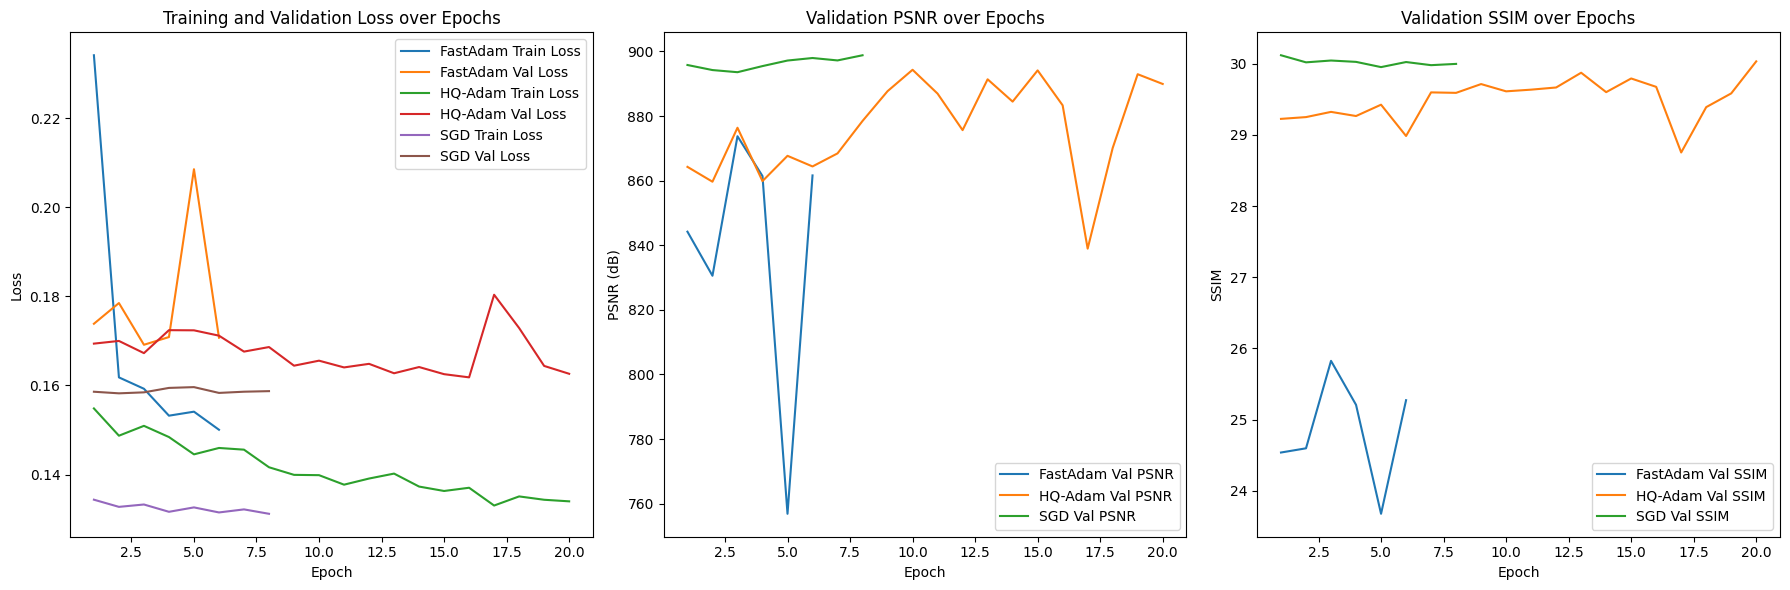

In [ ]:
import matplotlib.pyplot as plt

# Assuming `training_history` and `CONFIG` are available from the previous cell's execution

# Plotting the metrics
plt.figure(figsize=(18, 6))

# Plot Loss
plt.subplot(1, 3, 1)
epochs_fast_adam = range(1, CONFIG['fast_adam_epochs'] + 1)
epochs_hq_adam = range(1, CONFIG['hq_adam_epochs'] + 1)
epochs_sgd = range(1, CONFIG['sgd_epochs'] + 1)

plt.plot(epochs_fast_adam, training_history['fast_adam_train_loss'], label='FastAdam Train Loss')
plt.plot(epochs_fast_adam, training_history['fast_adam_val_loss'], label='FastAdam Val Loss')
plt.plot(epochs_hq_adam, training_history['hq_adam_train_loss'], label='HQ-Adam Train Loss')
plt.plot(epochs_hq_adam, training_history['hq_adam_val_loss'], label='HQ-Adam Val Loss')
plt.plot(epochs_sgd, training_history['sgd_train_loss'], label='SGD Train Loss')
plt.plot(epochs_sgd, training_history['sgd_val_loss'], label='SGD Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()

# Plot PSNR
plt.subplot(1, 3, 2)
plt.plot(epochs_fast_adam, training_history['fast_adam_val_psnr'], label='FastAdam Val PSNR')
plt.plot(epochs_hq_adam, training_history['hq_adam_val_psnr'], label='HQ-Adam Val PSNR')
plt.plot(epochs_sgd, training_history['sgd_val_psnr'], label='SGD Val PSNR')
plt.xlabel('Epoch')
plt.ylabel('PSNR (dB)')
plt.title('Validation PSNR over Epochs')
plt.legend()

# Plot SSIM
plt.subplot(1, 3, 3)
plt.plot(epochs_fast_adam, training_history['fast_adam_val_ssim'], label='FastAdam Val SSIM')
plt.plot(epochs_hq_adam, training_history['hq_adam_val_ssim'], label='HQ-Adam Val SSIM')
plt.plot(epochs_sgd, training_history['sgd_val_ssim'], label='SGD Val SSIM')
plt.xlabel('Epoch')
plt.ylabel('SSIM')
plt.title('Validation SSIM over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
!pip install scikit-image==0.19.3
!pip install image-quality
!pip install piq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 71.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.6/170.6 kB 7.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.6/146.6 kB 17.1 MB/s eta 0:00:00
  Created wheel for libsvm: filename=libsvm-3.23.0.4-cp312-cp312-linux_x86_64.whl size=251415 sha256=6104a460df863edaaaf1f236f698be08971a2c7b84577c04b42dbf75

In [ ]:
import torch
import os
import cv2
import numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from PIL import Image
import torch.nn as nn
import torch.nn.functional as F
from skimage import img_as_ubyte
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim
import imquality.brisque as brisque  # BRISQUE metric

# ==============================================================
# 🧩 Define Model: OptiFusionNet
# ==============================================================

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)
    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class ResidualDenoiseBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.act = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(ch)
    def forward(self, x):
        out = self.act(self.conv1(x))
        out = self.bn2(self.conv2(out))
        return x + out

class UpAddBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.proj = None
        if in_ch != skip_ch:
            self.proj = nn.Sequential(
                nn.Conv2d(in_ch, skip_ch, 1, bias=False),
                nn.BatchNorm2d(skip_ch),
                nn.ReLU(inplace=True)
            )
        self.conv = ConvBlock(skip_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
        if self.proj is not None:
            x = self.proj(x)
        if x.shape[1] != skip.shape[1]:
            proj = nn.Conv2d(skip.shape[1], x.shape[1], 1).to(skip.device)
            skip = proj(skip)
        fused = x + skip
        return self.conv(fused)

class OptiFusionNet(nn.Module):
    def __init__(self, in_ch=3, base_filters=64, res_blocks=3):
        super().__init__()
        self.inc = ConvBlock(in_ch, base_filters)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters, base_filters*2))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters*2, base_filters*4))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), ConvBlock(base_filters*4, base_filters*8))

        bch = base_filters * 8
        bl = [ConvBlock(bch, bch)]
        for _ in range(res_blocks):
            bl.append(ResidualDenoiseBlock(bch))
        self.bottleneck = nn.Sequential(*bl)

        self.up3 = UpAddBlock(bch, base_filters*8, base_filters*4)
        self.rdb3 = ResidualDenoiseBlock(base_filters*4)
        self.up2 = UpAddBlock(base_filters*4, base_filters*4, base_filters*2)
        self.rdb2 = ResidualDenoiseBlock(base_filters*2)
        self.up1 = UpAddBlock(base_filters*2, base_filters*2, base_filters)
        self.rdb1 = ResidualDenoiseBlock(base_filters)

        self.fusion_conv = nn.Sequential(
            nn.Conv2d(base_filters, base_filters, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base_filters, in_ch, 1)
        )
        self.refiner = ResidualDenoiseBlock(in_ch)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        b = self.bottleneck(x4)
        u3 = self.up3(b, x4); u3 = self.rdb3(u3)
        u2 = self.up2(u3, x3); u2 = self.rdb2(u2)
        u1 = self.up1(u2, x2); u1 = self.rdb1(u1)
        if u1.shape[2:] != x1.shape[2:]:
            u1 = F.interpolate(u1, size=x1.shape[2:], mode='bilinear', align_corners=False)
        if u1.shape[1] != x1.shape[1]:
            proj = nn.Conv2d(u1.shape[1], x1.shape[1], 1).to(u1.device)
            u1 = proj(u1)
        fused = u1 + x1
        res = self.fusion_conv(fused)
        out = torch.clamp(x + self.refiner(res), 0.0, 1.0)
        return out

# ==============================================================
# 🧠 LOAD TRAINED MODEL
# ==============================================================

MODEL_PATH = "/content/optifusionnet_multistage_best.pth"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"📦 Loading model weights from: {MODEL_PATH}")
model = OptiFusionNet().to(DEVICE)

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
if "model_state" in checkpoint:
    model.load_state_dict(checkpoint["model_state"])
else:
    model.load_state_dict(checkpoint)
model.eval()
print("✅ Model successfully loaded!")

# ==============================================================
# 🧾 TEST DATASET (SUPPORTS TIFF)
# ==============================================================

class NoGroundTruthDataset(Dataset):
    def __init__(self, folder, transform=None):
        self.folder = folder
        self.files = sorted([
            os.path.join(folder, f)
            for f in os.listdir(folder)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))
        ])
        self.transform = transform or transforms.Compose([transforms.ToTensor()])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_tensor = self.transform(img)
        return img_tensor, img_path

# ==============================================================
# PSNR + SSIM + BRISQUE FUNCTION
# ==============================================================

def compute_metrics(original, enhanced):
    orig_np = original.squeeze().cpu().numpy().transpose(1,2,0)
    enh_np = enhanced.squeeze().detach().cpu().numpy().transpose(1,2,0)
    psnr_val = compare_psnr(orig_np, enh_np, data_range=1.0)
    ssim_val = compare_ssim(orig_np, enh_np, channel_axis=2, data_range=1.0)
    return psnr_val, ssim_val

def compute_brisque(image_tensor):
    img = image_tensor.squeeze().detach().cpu().numpy().transpose(1,2,0)
    img_uint8 = img_as_ubyte(img)
    try:
        score = brisque.score(img_uint8)
    except:
        score = -1  # fallback if calculation fails
    return score

# ==============================================================
# ⚙️ INFERENCE LOOP WITH BRISQUE
# ==============================================================

TEST_DIR = "/content/drive/MyDrive/IPD/DATA/test/comtestSN"
SAVE_DIR = "/content/drive/MyDrive/IPD/opti_results"
os.makedirs(SAVE_DIR, exist_ok=True)

test_dataset = NoGroundTruthDataset(TEST_DIR)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

print(f"🧪 Found {len(test_dataset)} test images in {TEST_DIR}")

metrics_log = []

with torch.no_grad():
    for img_tensor, path in tqdm(test_loader):
        img_tensor = img_tensor.to(DEVICE)
        output = model(img_tensor)

        # Compute metrics
        psnr_val, ssim_val = compute_metrics(img_tensor, output)
        brisque_val = compute_brisque(output)

        # Prepare image for saving
        out_img = output.squeeze().detach().cpu().clamp(0,1).numpy()
        out_img = np.transpose(out_img, (1,2,0))
        out_img = (out_img * 255).astype(np.uint8)
        out_img = np.ascontiguousarray(out_img)

        # Overlay metrics
        filename = os.path.basename(path[0])
        text = f"PSNR:{psnr_val:.2f} SSIM:{ssim_val:.3f} BRISQUE:{brisque_val:.2f}"
        cv2.putText(out_img, text, (10,30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2, cv2.LINE_AA)

        # Save image
        save_path = os.path.join(SAVE_DIR, f"enhanced_{filename}")
        cv2.imwrite(save_path, cv2.cvtColor(out_img, cv2.COLOR_RGB2BGR))

        metrics_log.append((filename, psnr_val, ssim_val, brisque_val))
        print(f"{filename} → PSNR:{psnr_val:.2f} | SSIM:{ssim_val:.4f} | BRISQUE:{brisque_val:.2f}")

# ==============================================================
# PRINT METRICS SUMMARY
# ==============================================================

print("\n📊 Per Image Metrics:")
print("--------------------------------------------------")
for name, p, s, b in metrics_log:
    print(f"{name:20s} PSNR:{p:.2f}  SSIM:{s:.4f}  BRISQUE:{b:.2f}")
print("--------------------------------------------------")

📦 Loading model weights from: /content/optifusionnet_multistage_best.pth


FileNotFoundError: [Errno 2] No such file or directory: '/content/optifusionnet_multistage_best.pth'